<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/EfficientNetB0_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Работа с EfficientNetB0

EfficientNetB0 (Transfer Learning): This model uses a pre-trained EfficientNetB0 backbone with its weights frozen. A custom classification head—consisting of a Global Average Pooling layer, a Dense layer, and a Dropout layer—was added on top for the specific task of posture classification.

Optimizer: Adam

Loss Function: Binary Crossentropy

Epochs: 15

Data Augmentation: To improve generalization, the training data was augmented
with random horizontal flips, rotations, and zooms.

Both models were evaluated on an unseen test set of 27 images. While they achieved the same overall accuracy, their performance characteristics on a per-class basis were notably different.

Transfer learning tutorial - https://www.tensorflow.org/tutorials/images/transfer_learning

In [13]:
import shutil
import os
import cv2
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.applications import EfficientNetB0
from keras import layers
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [25]:
from google.colab import drive
drive.mount('content/')

Mounted at content/


In [ ]:
# # операция проведена один раз для копирования файлов из старого датасета в новый
# from_folder = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_MLP_dataset'
# new_folder = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset'

# from_test_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_Test'
# to_test_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_Test'

# folders_names = {
#     'bend_over': 'bad',
#     'body_left': 'bad',
#     'body_right': 'bad',
#     'head_left': 'bad',
#     'head_right': 'bad',
#     'too_close': 'bad',
#     'tilt_back': 'bad',
#     'correct': 'good'
# }

# for prev_category, new_category in folders_names.items():
#   prev_path = os.path.join(from_folder, prev_category)
#   new_path = os.path.join(new_folder, new_category)

#   prev_test_path = os.path.join(from_test_path, prev_category)
#   new_test_path = os.path.join(to_test_path, new_category)

#   os.makedirs(new_path, exist_ok=True)
#   os.makedirs(new_test_path, exist_ok=True)

#   for photo in os.listdir(prev_path):
#     old_photo = os.path.join(prev_path, photo)
#     new_photo = os.path.join(new_path, photo)
#     if os.path.exists(new_photo):
#       photo_name, photo_type = os.path.splitext(new_photo)
#       count = 1
#       while (os.path.exists(os.path.join(new_path, f"{photo_name}_{count}{photo_type}"))):
#         count += 1
#       new_photo = os.path.join(new_path, f"{photo_name}_{count}{photo_type}")
#     shutil.copy2(old_photo, new_photo)

#   for photo in os.listdir(prev_test_path):
#     old_photo = os.path.join(prev_test_path, photo)
#     new_photo = os.path.join(new_test_path, photo)
#     if os.path.exists(new_photo):
#       photo_name, photo_type = os.path.splitext(new_photo)
#       count = 1
#       while (os.path.exists(os.path.join(new_test_path, f"{photo_name}_{count}{photo_type}"))):
#         count += 1
#       new_photo = os.path.join(new_test_path, f"{photo_name}_{count}{photo_type}")
#     shutil.copy2(old_photo, new_photo)

In [6]:
bad_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/bad'
good_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/good'
print(len(os.listdir(good_path)))
print(len(os.listdir(bad_path)))

1537
1562


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Rescaling, Input

ds_dir = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/'
test_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_Test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# подготовка данных
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

Found 3099 files belonging to 2 classes.
Using 2480 files for training.
Found 3099 files belonging to 2 classes.
Using 619 files for validation.
Found 100 files belonging to 2 classes.


In [ ]:
base_model = EfficientNetB0(input_shape=(224, 224, 3),
                            include_top=False,
                            weights='imagenet')

base_model.trainable = False

model = Sequential([
    base_model,
    augmentation,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = keras.losses.BinaryCrossentropy(from_logits=False)
model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

checkpoint = 'tl_EfficientNetB0.h5'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max'
)

In [9]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=15,
                    callbacks=[checkpoint_callback]
                    )

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8311 - loss: 0.3462

78/78 ━━━━━━━━━━━━━━━━━━━━ 650s 4s/step - accuracy: 0.9181 - loss: 0.2015 - val_accuracy: 0.9838 - val_loss: 0.0509
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9812 - loss: 0.0642

78/78 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.9810 - loss: 0.0627 - val_accuracy: 0.9887 - val_loss: 0.0320
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9843 - loss: 0.0447

78/78 ━━━━━━━━━━━━━━━━━━━━ 275s 3s/step - accuracy: 0.9815 - loss: 0.0486 - val_accuracy: 0.9968 - val_loss: 0.0214
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.9867 - loss: 0.0375 - val_accuracy: 0.9935 - val_loss: 0.0173
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.9895 - loss: 0.0311 - val_accuracy: 0.9935 - val_loss: 0.0167
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.9911 - loss: 0.0255 - val_accuracy: 0.9968 - val_loss: 0.0100
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9931 - loss: 0.0214 - val_accuracy: 0.9919 - val_loss: 0.0194
Epoch 8/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.9952 - loss: 0.0187 - val_accuracy: 0.9952 - val_loss: 0.0094
Epoch 9/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.9940 - loss: 0.0166 - val_accuracy: 0.9952 - val_loss: 0.0105
Epoch 10/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.9935 - loss: 0.0172 - val_accuracy: 0.9952 - val_loss: 0

78/78 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.9960 - loss: 0.0119 - val_accuracy: 0.9984 - val_loss: 0.0061
Epoch 12/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.9952 - loss: 0.0142 - val_accuracy: 0.9984 - val_loss: 0.0070
Epoch 13/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9931 - loss: 0.0166 - val_accuracy: 0.9984 - val_loss: 0.0068
Epoch 14/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.9988 - loss: 0.0084 - val_accuracy: 0.9935 - val_loss: 0.0133
Epoch 15/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.9944 - loss: 0.0125 - val_accuracy: 0.9935 - val_loss: 0.0130


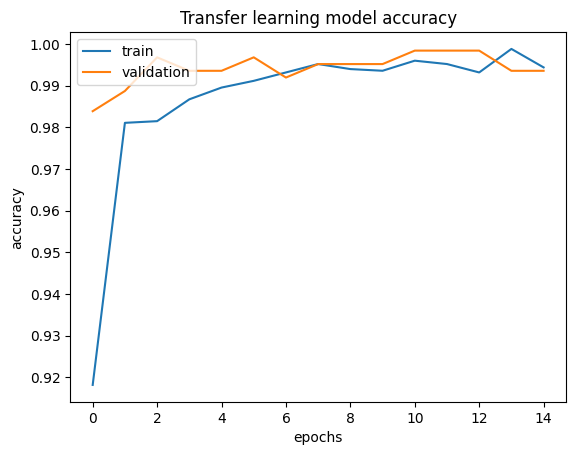

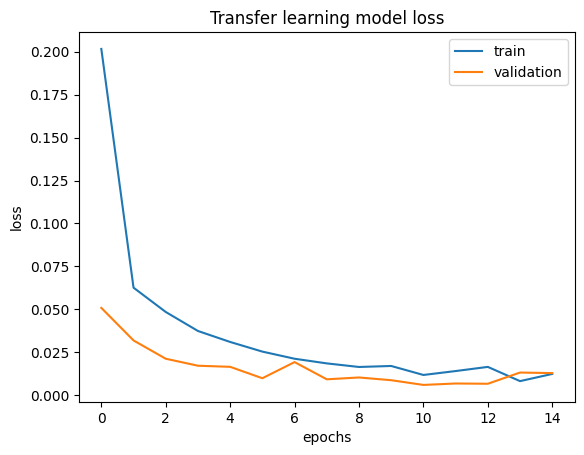

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Transfer learning model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["train", "validation"], loc="upper left")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Transfer learning model loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(["train", "validation"], loc="upper right")
plt.show()

In [11]:
!ls

content  sample_data  tl_EfficientNetB0.h5


Accuracy:  0.78
Precision:  0.8
Recall:  0.6
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]


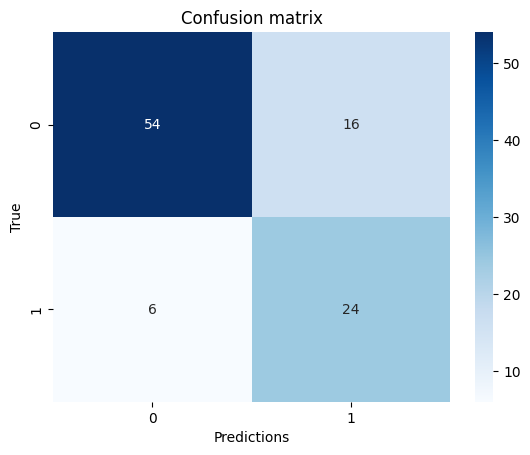

In [14]:
import seaborn as sns

saved_model = tf.keras.models.load_model('tl_EfficientNetB0.h5')

true_categories = []
pred_categories = []
for classes in os.listdir(test_path):
  class_path = test_path + '/' + classes
  for photo in os.listdir(class_path):
    # print(photo)
    photo_path = test_path + '/' + classes + '/' + photo
    # print(photo_path, classes)
    true_categories.append(classes)
    img = cv2.imread(photo_path)
    img = cv2.resize(img, (224, 224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    prediction = saved_model.predict(img, verbose=0)[0][0]
    # print(prediction)
    category = 0
    if prediction >= 0.5:
      category = 1
    else:
      category = 0
    pred_categories.append(category)

true_labels = []
for x in true_categories:
  if x == 'bad':
    true_labels.append(0)
  else:
    true_labels.append(1)

accuracy = accuracy_score(pred_categories, true_labels)
precision = precision_score(pred_categories, true_labels)
recall = recall_score(pred_categories, true_labels)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)

print(true_labels)
print(pred_categories)

matrix = confusion_matrix(true_labels, pred_categories)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predictions')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

Custom CNN: A lightweight Convolutional Neural Network built from scratch. The architecture consists of three convolutional blocks with MaxPooling, followed by a dense classifier with a Dropout layer for regularization.

Found 3099 files belonging to 2 classes.
Using 2480 files for training.
Found 3099 files belonging to 2 classes.
Using 619 files for validation.
Found 100 files belonging to 2 classes.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,234,977 (12.34 MB)

 Trainable params: 3,234,977 (12.34 MB)

...

78/78 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9234 - loss: 0.1780 - val_accuracy: 0.9435 - val_loss: 0.1352
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9371 - loss: 0.1561 - val_accuracy: 0.9418 - val_loss: 0.1389
Epoch 8/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9490 - loss: 0.1387

78/78 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9464 - loss: 0.1439 - val_accuracy: 0.9628 - val_loss: 0.1052
Epoch 9/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9399 - loss: 0.1475

78/78 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9387 - loss: 0.1517 - val_accuracy: 0.9661 - val_loss: 0.0873
Epoch 10/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9480 - loss: 0.1266 - val_accuracy: 0.9451 - val_loss: 0.1067
Epoch 11/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9532 - loss: 0.1196 - val_accuracy: 0.9661 - val_loss: 0.0819
Epoch 12/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9443 - loss: 0.1253

78/78 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9504 - loss: 0.1177 - val_accuracy: 0.9774 - val_loss: 0.0590
Epoch 13/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9593 - loss: 0.1020 - val_accuracy: 0.9758 - val_loss: 0.0586
Epoch 14/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9573 - loss: 0.1078 - val_accuracy: 0.9661 - val_loss: 0.0721
Epoch 15/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9588 - loss: 0.1089

78/78 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9617 - loss: 0.0972 - val_accuracy: 0.9806 - val_loss: 0.0548


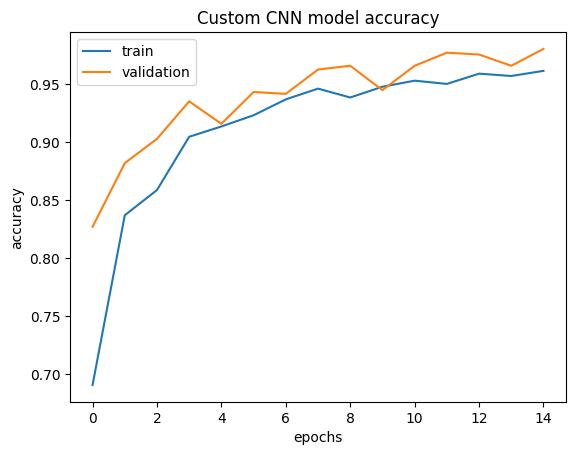

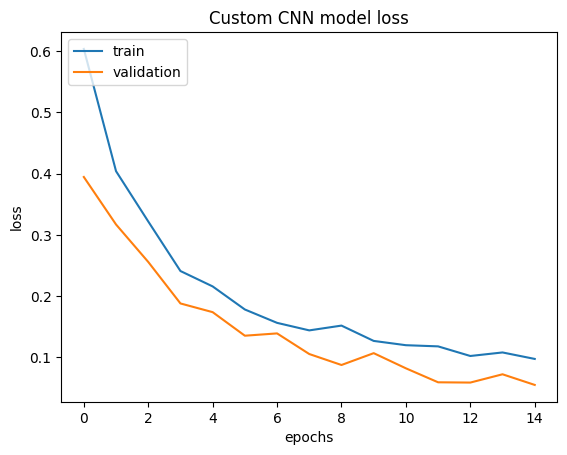

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Rescaling, Input

ds_dir = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/'
test_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_Test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# подготовка данных
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

filers_size = (3, 3)

custom_cnn_model = Sequential([
    Input(shape=(224, 224, 3)),
    Rescaling(1./255),
    augmentation,
    Conv2D(16, filers_size, activation='relu', padding='same'),
    MaxPooling2D(),

    Conv2D(32, filers_size, activation='relu', padding='same'),
    MaxPooling2D(),

    Conv2D(64, filers_size, activation='relu', padding='same'),
    MaxPooling2D(),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = keras.losses.BinaryCrossentropy(from_logits=False)
custom_cnn_model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

custom_cnn_model.summary()

checkpoint = 'custom_cnn_model.h5'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max'
)

history = custom_cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint_callback]
)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Custom CNN model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["train", "validation"], loc="upper left")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Custom CNN model loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(["train", "validation"], loc="upper left")
plt.show()

Accuracy:  0.74
Precision:  0.6333333333333333
Recall:  0.5588235294117647
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1]


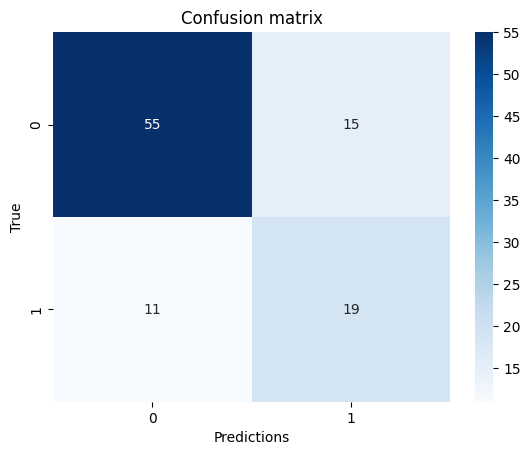

In [26]:
saved_cnn_model = tf.keras.models.load_model('custom_cnn_model.h5')

true_categories = []
pred_categories = []
for classes in os.listdir(test_path):
  class_path = test_path + '/' + classes
  for photo in os.listdir(class_path):
    # print(photo)
    photo_path = test_path + '/' + classes + '/' + photo
    # print(photo_path, classes)
    true_categories.append(classes)
    img = cv2.imread(photo_path)
    img = cv2.resize(img, (224, 224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    prediction = saved_cnn_model.predict(img, verbose=0)[0][0]
    # print(prediction)
    category = 0
    if prediction >= 0.5:
      category = 1
    else:
      category = 0
    pred_categories.append(category)

true_labels = []
for x in true_categories:
  if x == 'bad':
    true_labels.append(0)
  else:
    true_labels.append(1)

accuracy = accuracy_score(pred_categories, true_labels)
precision = precision_score(pred_categories, true_labels)
recall = recall_score(pred_categories, true_labels)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)

print(true_labels)
print(pred_categories)

matrix = confusion_matrix(true_labels, pred_categories)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predictions')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

In [27]:
!ls

content  custom_cnn_model.h5  drive  sample_data  tl_EfficientNetB0.h5
